# Health Emergencies Preparedness and Response Program (HEPR)
# Tutorial, Module 3: Disruption

### Matteo Mastropierro and Dunstan Matekenya

This notebook is a template workflow to collect data and prepare the main data to perform a baseline physical accessibility analysis to health facilities. It uses various tools developed by the World Bank's Geospatial Operations Support Team (GOST).

This notebook represents the first module of the tutorial on the physical accessibility to health facilities in a context of emergency. \
It focuses on the datasets and the functions to be used to perform the analysis. A particular focus will be put on the uncertainty and pros&cons deriving from the utilization of different datasets. \


## Setup

Import packages required for the analysis

In [229]:
# System
import sys
import os
from os.path import join, expanduser
from pathlib import Path
# Avoid warnings to pop up
import warnings
warnings.filterwarnings('ignore')

In [230]:
# Visualization tools
# import folium as flm
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.gridspec as gridspec
from rasterio.plot import plotting_extent
from rasterio.plot import show
from mpl_toolkits.axes_grid1 import make_axes_locatable
import contextily as ctx
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns

os.environ['CARTOPY_USER_BACKGROUNDS'] = '/home/jupyter-wb618081/Python/Backgrounds/'

In [231]:
# Processing 
import numpy as np
import geopandas as gpd
import pandas as pd
from gadm import GADMDownloader
import dask_geopandas as dask_gpd

# Raster
import rasterio as rio
from rasterio.features import shapes
from shapely.geometry import box
from rasterio.features import geometry_mask
from rasterstats import zonal_stats
from shapely.geometry import Polygon, box, Point
from shapely.geometry import mapping
import skimage.graph as graph
from scipy.signal import convolve2d

# Graph
import pickle
import networkx as nx
import osmnx as ox

# for facebook data
from pyquadkey2 import quadkey

In [232]:
# Climate/Flood
# import xarray as xr

In [233]:
# Define your path to the Repositories

sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'gostrocks', 'src'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'GOSTNets_Raster', 'src'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'GOSTnets'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'GOST_Urban', 'src', 'GOST_Urban'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'health-equity-diagnostics', 'src', 'modules'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'INFRA_SAP'))

import GOSTnets as gn
from GOSTnets.load_osm import *
import GOSTRocks.rasterMisc as rMisc
from GOSTRocks.misc import get_utm
import GOSTNetsRaster.market_access as ma
import UrbanRaster as urban

from infrasap import aggregator
from infrasap import osm_extractor as osm   

from utils import download_osm_shapefiles

In [234]:
# auto reload
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Define below the local folder where you are located

In [235]:
scratch_dir = join(expanduser("/home/jupyter-wb618081"), 'Health-Access-Metrics', 'Tutorials')
data_dir = join(scratch_dir, 'tutorial_data')
out_path = join(scratch_dir, 'tutorial_output')

In [236]:
## Function for creating a path, if needed ##
def checkDir(out_path):
    if not os.path.exists(out_path):
        os.makedirs(out_path)

## Data Preparation

### Import the City boundaries (.shp)

In [237]:
epsg = "EPSG:4326"
epsg_utm = "EPSG:28232"

In [238]:
city = gpd.read_file((data_dir+"/brazaville.shp"))
city.to_crs(epsg)
city

,ID_0,COUNTRY,NAME_1,NL_NAME_1,ID_2,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
0,COG,Republic of the Congo,Brazzaville,NaN,COG.2.1_1,Brazzaville,NaN,NaN,District,District,NaN,CG.BR.BR,"POLYGON ((15.32458 -4.28091, 15.31317 -4.27887..."


### Import the Road Network (.shp)

Download from the link above the OpenStreetMap road network from Geofabrik

In [239]:
roads_osm = OSM_to_network(join(data_dir,"congo-brazzaville-latest.osm.pbf"))

GOSTNets creates a special 'OSM_to_network' object. This object gets initialized with both a copy of the OSM file itself and the roads extracted from the OSM file in a GeoPandas DataFrame. This DataFrame is a property of the object called 'roads_raw' and is the starting point for our network.

In [240]:
?roads_osm

Type:           OSM_to_network
String form:    <GOSTnets.load_osm.OSM_to_network object at 0x729f658d37c0>
File:           ~/Repos/GOSTnets/GOSTnets/load_osm.py
Docstring:     
Object to load OSM PBF to networkX objects.

Object to load OSM PBF to networkX objects.     EXAMPLE:     G_loader = losm.OSM_to_network(bufferedOSM_pbf)     G_loader.generateRoadsGDF()     G = G.initialReadIn() 
snap origins and destinations     o_snapped = gn.pandana_snap(G, origins)     d_snapped = gn.pandana_snap(G, destinations)     
Init docstring: Generate a networkX object from a osm file

In [241]:
roads_gdf = roads_osm.roads_raw
roads_osm.roads_raw.head()

,osm_id,infra_type,one_way,bridge,geometry
0,4692113,primary,True,False,"LINESTRING (15.23126 -4.29689, 15.23134 -4.296..."
1,4692179,primary,True,False,"LINESTRING (15.25202 -4.28510, 15.25210 -4.285..."
2,4692181,primary,True,False,"LINESTRING (15.24010 -4.29174, 15.23988 -4.291..."
3,4692231,primary,True,False,"LINESTRING (15.28165 -4.27427, 15.28176 -4.274..."
4,4692245,primary,True,False,"LINESTRING (15.25944 -4.28030, 15.25946 -4.280..."


In [242]:
?roads_osm.roads_raw

Type:        GeoDataFrame
String form:
osm_id   infra_type  one_way  bridge  \
           0         4692113      primary     True   Fals <...>  -4.785...
           54721  LINESTRING (11.94277 -4.78254, 11.94306 -4.784...
           
           [54722 rows x 5 columns]
Length:      54722
File:        ~/.conda/envs/geo_wb_linux/lib/python3.8/site-packages/geopandas/geodataframe.py
Docstring:  
A GeoDataFrame object is a pandas.DataFrame that has a column
with geometry. In addition to the standard DataFrame constructor arguments,
GeoDataFrame also accepts the following keyword arguments:

Parameters
----------
crs : value (optional)
    Coordinate Reference System of the geometry objects. Can be anything accepted by
    :meth:`pyproj.CRS.from_user_input() <pyproj.crs.CRS.from_user_input>`,
    such as an authority string (eg "EPSG:4326") or a WKT string.
geometry : str or array (optional)
    If str, column to use as geometry. If array, will be set as 'geometry'
    column on GeoDataFram

In [243]:
roads_osm.roads_raw.infra_type.value_counts()

infra_type
residential       35414
track              7667
unclassified       3599
path               2504
service            1696
tertiary           1608
trunk               746
secondary           655
primary             409
footway             297
primary_link         36
trunk_link           27
construction         21
tertiary_link        20
secondary_link        9
living_street         5
steps                 4
pedestrian            3
yes                   2
Name: count, dtype: int64

We can show the different highway types and counts


We need to define a list of the types of roads from the above that we consider acceptable for our road network

In [244]:
accepted_road_types = ['residential', 'track','unclassified','path', 'service','tertiary','trunk','secondary','primary',
                       'footway','primary_link','trunk_link','secondary_link','tertiary_link']

We can therefore filter our roads using the **filterRoads** method

In [245]:
roads_osm.filterRoads(acceptedRoads = accepted_road_types)

In [246]:
roads_osm.roads_raw.infra_type.value_counts()

infra_type
residential       35414
track              7667
unclassified       3599
path               2504
service            1696
tertiary           1608
trunk               746
secondary           655
primary             409
footway             297
primary_link         36
trunk_link           27
tertiary_link        20
secondary_link        9
Name: count, dtype: int64

We are interested in the area of the capital city of Congo, Brazzaville. We therefore clip the road network to the shapefile of the city

,ID_0,COUNTRY,NAME_1,NL_NAME_1,ID_2,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
0,COG,Republic of the Congo,Brazzaville,NaN,COG.2.1_1,Brazzaville,NaN,NaN,District,District,NaN,CG.BR.BR,"POLYGON ((15.32458 -4.28091, 15.31317 -4.27887..."


<Axes: >

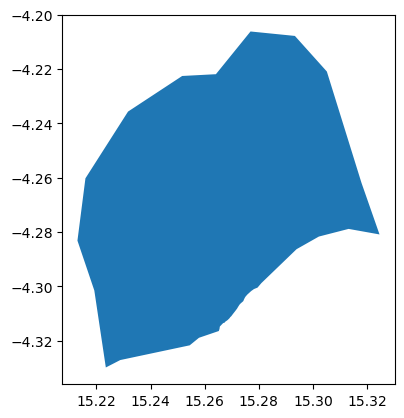

In [247]:
# This is the GeoPandas dataframe
display(city)
city.plot()

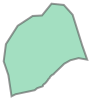

In [248]:
# This is the Shapely geometry object contained in the geodf
city_shp = city.geometry[0]
city_shp

We check to see everything lines up by running intersect and counting the True / False returns. The count of the True values are the number of roads that intersect the AOI \
**intersects** is a Shapely function that returns True if the boundary or interior of the object intersect in any way with those of the other


In [249]:
roads_osm.roads_raw.to_crs(epsg)
print(roads_osm.roads_raw.crs)
print(city.crs)

+init=epsg:4326 +type=crs
EPSG:4326


In [250]:
roads_osm.roads_raw.geometry.intersects(city_shp).value_counts()

False    48701
True      5986
Name: count, dtype: int64

We can therefore remove any roads that does not intersect Brazzaville administrative unit

In [251]:
roads_osm.roads_raw = roads_osm.roads_raw.loc[roads_osm.roads_raw.geometry.intersects(city_shp) == True]

Now we generate the RoadsGPD object, which is stored as a property of the 'OSM_to_network' object. The RoadsGPD object is a GeoDataFrame that further processes the roads.\
This includes splitting the edges where intersections occur, adding unique edge IDs, and adding to/from columns to the GeoDataFrame.\
We can do this using the **generateRoadsGDF** function

In [252]:
roads_osm.generateRoadsGDF(verbose = False)

We use the **initialReadIn()** function to transform this to a graph object

In [253]:
roads_osm.initialReadIn()

In [254]:
?roads_osm.network

Type:           MultiDiGraph
String form:    MultiDiGraph with 14031 nodes and 21554 edges
Length:         14031
File:           ~/.conda/envs/geo_wb_linux/lib/python3.8/site-packages/networkx/classes/multidigraph.py
Docstring:     
A directed graph class that can store multiedges.

Multiedges are multiple edges between two nodes.  Each edge
can hold optional data or attributes.

A MultiDiGraph holds directed edges.  Self loops are allowed.

Nodes can be arbitrary (hashable) Python objects with optional
key/value attributes. By convention `None` is not used as a node.

Edges are represented as links between nodes with optional
key/value attributes.

Parameters
----------
incoming_graph_data : input graph (optional, default: None)
    Data to initialize graph. If None (default) an empty
    graph is created.  The data can be any format that is supported
    by the to_networkx_graph() function, currently including edge list,
    dict of dicts, dict of lists, NetworkX graph, 2D NumPy arra

We save this graph object down to file using **gn.save()**. \
The save function produces three outputs: a node GeoDataFrame as a CSV, an edge GeoDataFrame as a CSV, and a graph object saved as a pickle (check your folder!).

In [255]:
gn.save(roads_osm.network,'roads_brazzaville',out_path)

### Import Flood extent and depth (.tif)

Here, we import Fathom v2 Pluvial and Fluvial flood data (.tif) of 100 yr return period. \
This represents and mimics one of the impacts that climate has on infrastructure and the disruption of the accessibility to health facilities.  

In [256]:
flood_fluvial = rio.open(join(data_dir,"FU_1in100.tif")) #.read(1)
flood_pluvial = rio.open(join(data_dir,"P_1in100.tif")) #.read(1)

We can check the metadata, resolution and extent of the raster (in degrees)

In [257]:
meta = flood_pluvial.meta
meta

{'driver': 'GTiff',
 'dtype': 'float32',
 'nodata': None,
 'width': 10000,
 'height': 11000,
 'count': 1,
 'crs': CRS.from_epsg(4326),
 'transform': Affine(0.0008333333333333334, 0.0, 11.157916666668333,
        0.0, -0.0008333333333333334, 3.7495833336863327)}

In [258]:
flood_pluvial.bounds

BoundingBox(left=11.157916666668333, bottom=-5.417083332980335, right=19.491250000001667, top=3.7495833336863327)

In [259]:
flood_pluvial.res

(0.0008333333333333334, 0.0008333333333333334)

Rasterio datasets generally have one or more bands (e.g. EO images). \
Following the GDAL convention, these bands are indexed starting with the number 1 (we have just 1 band in this case) \
We import the file with the **open()** and **read()** function as a numpy.array

In [260]:
flood_fluvial = flood_fluvial.read(1)
flood_pluvial = flood_pluvial.read(1)

In [261]:
flood_fluvial

array([[-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       ...,
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.]],
      dtype=float32)

The two datasets have different missing values: 
* FLUVIAL: \
    not-flooded areas = -9999 \
    inland water bodies and ocean = 999 
* PLUVIAL: \
    not-flooded areas = 0 \
    inland water bodies and ocean = 999

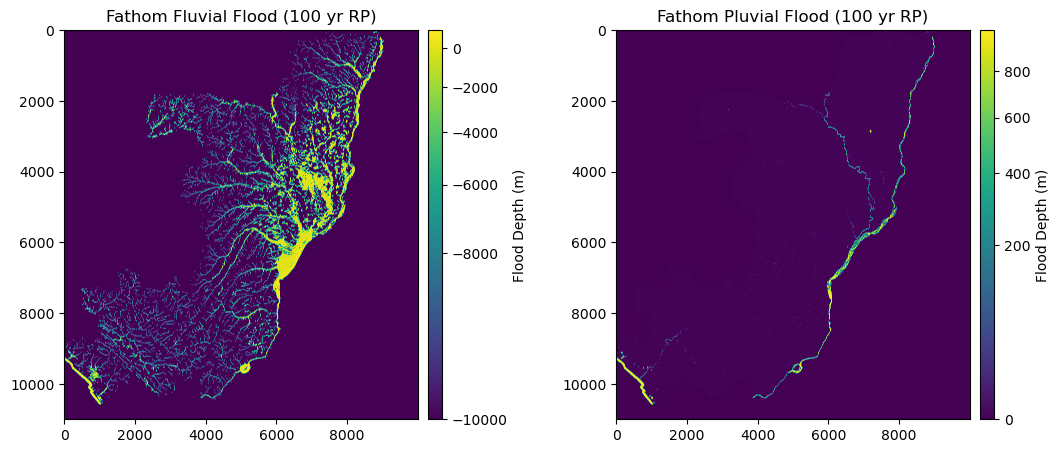

In [262]:
fig = plt.figure(figsize=(12, 8))  # Increase width to accommodate two panels
grid = fig.add_gridspec(1, 3, width_ratios=[1, 0.05, 1], wspace=0.3)  # Create grid layout

# First panel
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title("Fathom Fluvial Flood (100 yr RP)", fontsize=12, horizontalalignment='center')
im1 = ax1.imshow(flood_fluvial, norm=colors.PowerNorm(gamma=0.5), cmap='viridis')
divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes('right', size="4%", pad=0.1)
cb1 = fig.colorbar(im1, cax=cax1, orientation='vertical')
cb1.set_label("Flood Depth (m)")

# Second panel
ax2 = fig.add_subplot(grid[0, 2])
ax2.set_title("Fathom Pluvial Flood (100 yr RP)", fontsize=12, horizontalalignment='center')
im2 = ax2.imshow(flood_pluvial, norm=colors.PowerNorm(gamma=0.5), cmap='viridis')
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes('right', size="4%", pad=0.1)
cb2 = fig.colorbar(im2, cax=cax2, orientation='vertical')
cb2.set_label("Flood Depth (m)")

plt.show()

We want to consider both the scenarios, therefore we preserve, among the two, the maximum flood depth

In [263]:
flood = np.fmax(flood_fluvial, flood_pluvial)

We can export and save the combined Flood dataset as a .tif file 

In [264]:
with rio.open(join(data_dir,"Fmax_1in100.tif"), 'w', **meta) as dst:
            dst.write(flood, 1)
flood = rio.open(join(data_dir,"Fmax_1in100.tif"))

For the moment, we are only interested in Brazaville city, therefore we clip our raster with the city shapefile. \
We can accomplish that by using the **clipRaster** function of GOSTrock library:

In [265]:
rMisc.clipRaster(flood, city, join(data_dir,"Fmax_1in100_clip.tif"), crop=True)
flood = rio.open(join(data_dir,"Fmax_1in100_clip.tif"))

For simplicity, we just substitute the value for open waters (999) to 0

In [266]:
flood_data = flood.read(1)

In [267]:
flood_data[flood_data == 999] = 0

### Import the Health Facilities (destinations)

Health facilities are stored as Geopandas dataframe

In [268]:
hf = gpd.read_file((data_dir+"/hf_COG.shp"))

In [269]:
hf = hf[hf.geometry.intersects(city_shp)]

In [270]:
display('The following categories and numbers of Health Facilities are considered to perform the analysis: ')
display(hf["Facility t"].value_counts())

'The following categories and numbers of Health Facilities are considered to perform the analysis: '

Facility t
Centre de Santé Intégré    22
l?Hôpital de Base           2
University Hospital         1
Name: count, dtype: int64

### Import Population (origin)

In [271]:
# wp_path = join(expanduser("R:/"), 'Data', 'GLOBAL/Population/WorldPop_PPP_2020/MOSAIC_ppp_prj_2020', f'ppp_prj_2020_{iso}.tif') # Download from link above
wp_path = join(data_dir, f'ppp_2020_1km_Aggregated.tif') # Download from link above

pop_surf = rio.open(wp_path)

In [272]:
pop_surf.res

(0.0083333333, 0.0083333333)

## Health Facilities flood disruption

Health facilities impacted by floods are identified. Similarly to the roads, when water level is >20 cm, the HF is considered as disrupted.

In [273]:
coords = [(x,y) for x, y in zip(hf.geometry.x, hf.geometry.y)]
hf["Flood_100"] = [x[0] for x in flood.sample(coords)]

In [274]:
hf_flooded = hf[hf["Flood_100"] > 0.2]
hf_dry = hf[~hf.index.isin(hf_flooded.index)]

## Road network flood disruption

Floods can impact all the roads, except the bridges in primary and secondary roads

In [275]:
flood_road = flood.read(1).copy()
safe_crit = ((roads_osm.roads_raw['bridge'] == "True") & ((roads_osm.roads_raw['infra_type'] == "primary") | (roads_osm.roads_raw['infra_type'] == "secondary")))
roads_safe = roads_osm.roads_raw[safe_crit]
roads_flood = roads_osm.roads_raw[~safe_crit]

Subsequently, we consider that if water level is more than 20 cm, the road is disrupted. \
Therefore we mask our flood raster dataset, retaining only those pixels for which the flood depth is > 0.2 m

In [276]:
transf = flood.transform
mask = (flood_road >= 0.2)

Now, we have the roads stored as VECTORS (geodf) and the flood surface as RASTER (numpy). \
To disrupt the roads network, we need to intersect the two datasets. \
To do that, one option is to transform the flood raster into a vector polygon

In [277]:
# Create Polygons only from those cells where mask = True (water level >= 20 cm) 
def raster_cells_to_polygons(mask, transform):
    
    polygons = []
    for (row, col), value in np.ndenumerate(mask):
            if value:         # Only create polygons where the mask is True
                # Get the coordinates of the top left corner of the cell
                top_left = rio.transform.xy(transform, row, col, offset='ul')
                # Since each cell is a square, calculate the bottom right corner
                bottom_right = rio.transform.xy(transform, row+1, col+1, offset='ul')
                # Create a polygon from these coordinates
                polygon = box(top_left[0], bottom_right[1], bottom_right[0], top_left[1])
                polygons.append(polygon)
                
    return polygons

In [278]:
# Vectorize the masked cells
flood_poly = raster_cells_to_polygons(mask, transf)
flood_poly_gdf = gpd.GeoDataFrame(geometry=flood_poly, crs=epsg)  # Make sure to set the correct CRS


In [279]:
flood_poly_gdf

,geometry
0,"POLYGON ((15.28792 -4.21208, 15.28792 -4.21125..."
1,"POLYGON ((15.28792 -4.21292, 15.28792 -4.21208..."
2,"POLYGON ((15.28875 -4.21292, 15.28875 -4.21208..."
3,"POLYGON ((15.29792 -4.21292, 15.29792 -4.21208..."
4,"POLYGON ((15.29875 -4.21292, 15.29875 -4.21208..."
...,...
4005,"POLYGON ((15.22458 -4.32958, 15.22458 -4.32875..."
4006,"POLYGON ((15.22542 -4.32958, 15.22542 -4.32875..."
4007,"POLYGON ((15.22625 -4.32958, 15.22625 -4.32875..."
4008,"POLYGON ((15.22375 -4.33042, 15.22375 -4.32958..."


Now that our flood dataset is a GeoPandas DataFrame, we can compute the intersection with the road network

In [280]:
intersect = gpd.sjoin(roads_flood, flood_poly_gdf, how="inner", op='intersects')

We remove the duplicates, since one road could be intersected by multiple flooded cells, and thus appear multiple times in the results

In [281]:
intersect.drop_duplicates(subset="osm_id", inplace = True)
intersect

,osm_id,infra_type,one_way,bridge,geometry,index_right
3,4692231,primary,True,False,"LINESTRING (15.28165 -4.27427, 15.28176 -4.274...",1670
5,4692249,primary,True,False,"LINESTRING (15.26843 -4.28297, 15.26847 -4.282...",1670
27,23342339,residential,False,False,"LINESTRING (15.27811 -4.27821, 15.27909 -4.277...",1670
244,37363116,unclassified,False,False,"LINESTRING (15.28150 -4.27443, 15.28160 -4.274...",1670
26845,422471832,primary,True,False,"LINESTRING (15.28163 -4.27433, 15.28165 -4.274...",1670
...,...,...,...,...,...,...
48823,775215093,path,False,True,"LINESTRING (15.24864 -4.27662, 15.24864 -4.276...",1901
48800,773158924,path,False,True,"LINESTRING (15.24610 -4.27926, 15.24599 -4.279...",1953
54201,1222996295,service,False,False,"LINESTRING (15.29389 -4.27222, 15.29371 -4.272...",1583
54202,1222996296,footway,False,False,"LINESTRING (15.29378 -4.27264, 15.29369 -4.272...",1583


Finally, we remove the roads that are flooded (intersect) by matching their index, and modify the road network merging the "safe" roads with the disrupted.


In [282]:
roads_impact = roads_osm.roads_raw.drop(intersect.index)
roads_osm.roads_raw = pd.concat([roads_impact, roads_safe], axis = 0)

We apply the following commands again, to update the graph object considering the flooding scenario: 

In [283]:
roads_osm.generateRoadsGDF(verbose = False)
roads_osm.initialReadIn()

We save the graph object of the flooded roads down to file using **gn.save()**.

In [285]:
gn.save(roads_osm.network,'roads_brazzaville_flooded',out_path)

Let's plot the location of the Health facilities, together with the flood dataset and the roads

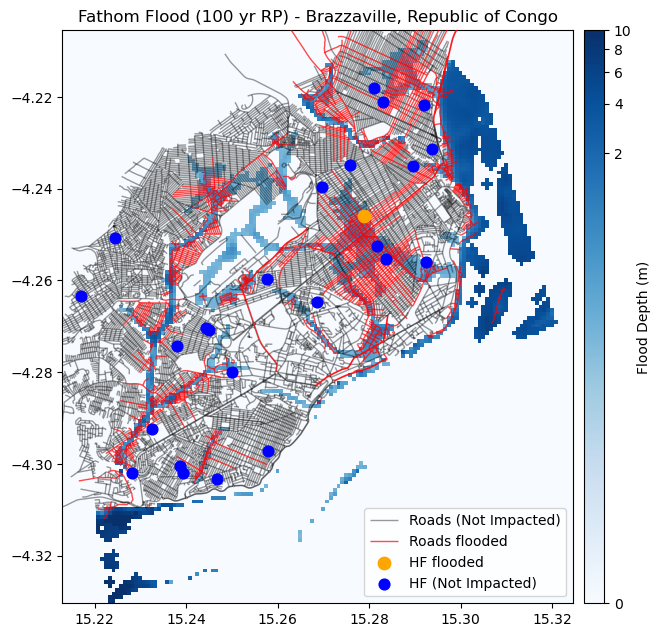

In [218]:
fig, ax = plt.subplots(figsize=(7, 8))
ax.set_title("Fathom Flood (100 yr RP) - Brazzaville, Republic of Congo", fontsize=12, horizontalalignment='center')

# Plot the flood data
flood_image = show(flood_data, transform=flood.transform, ax=ax, norm=colors.PowerNorm(gamma=0.15), cmap='Blues', alpha = 1, zorder = 2)

# Create an axis divider for the colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size="4%", pad=0.1)

# Add the colorbar
cb = fig.colorbar(flood_image.get_images()[0], cax=cax, orientation='vertical')
cb.set_label("Flood Depth (m)")

# Plot the road network not impcted
roads_osm.roads_raw.plot(ax=ax, color='black', linewidth=1, alpha = 0.4, zorder = 2, label='Roads (Not Impacted)')
# Plot the road network disrupted
intersect.plot(ax=ax, color='red', linewidth=1, alpha = 0.7, zorder = 3, label='Roads flooded')
# PLot the Health facilities flooded
hf_flooded.plot(ax=ax, color='orange', markersize = 80, zorder=3, label='HF flooded')
# Plot the Health facilities not affected
hf_dry.plot(ax=ax, color='blue', markersize = 60, zorder=3, label='HF (Not Impacted)')

ax.set_xlim(flood.bounds.left, flood.bounds.right)
ax.set_ylim(flood.bounds.bottom, flood.bounds.top)

ax.legend(loc='lower right')

plt.show()

## Calculate Betweeness centrality

In [286]:
with open(os.path.join(out_path, 'roads_brazzaville.gpickle'), 'rb') as f:
    G = pickle.load(f)

with open(os.path.join(out_path, 'roads_brazzaville_flooded.gpickle'), 'rb') as f:
    G_flood = pickle.load(f)

In [287]:
print(G)
print(G_flood)

MultiDiGraph with 14031 nodes and 21554 edges
MultiDiGraph with 10966 nodes and 15687 edges


In [288]:
def create_grid(bbox, x_distance, y_distance):
    x = np.arange(bbox[0], bbox[2], x_distance)
    y = np.arange(bbox[1], bbox[3], y_distance)
    Y, X = np.meshgrid(y, x, indexing="ij") 
    #create a iterable with the (x,y) coordinates
    points = [Point(x,y) for x, y in zip(X.flatten(),Y.flatten())]
    points_raw = [(x,y) for x, y in zip(X.flatten(),Y.flatten())]
    return gpd.GeoDataFrame(geometry=points, crs=4326)

In [289]:
start_points = create_grid(flood.bounds, 0.01, 0.01)

In [290]:
G_clean = gn.clean_network(G, UTM = epsg_utm, WGS = epsg, junctdist = 10, verbose = False)
G_flood_clean = gn.clean_network(G_flood, UTM = epsg_utm, WGS = epsg, junctdist = 10, verbose = False)

21554
completed processing 43108 edges
20985
completed processing 41970 edges
Edge reduction: 21554 to 41970 (-94 percent)
15687
completed processing 31374 edges
15205
completed processing 30410 edges
Edge reduction: 15687 to 30410 (-93 percent)


In [291]:
G.graph['crs'] = epsg
G_flood.graph['crs'] = epsg

Calculate the betweeeness centrality under both normal and flooded conditions. /
- find the shortest path from the origin (point on grid) to the destination (HF)
- retrieve all the edges along the shortest path
- count the number of times an edge is part of a shortest path 

In [292]:
%%time

routes = []
for i, h in hf.iterrows():
   for i, s in start_points.iterrows():
        orig = ox.nearest_nodes(G, Y=s.geometry.y, X=s.geometry.x)
        dest = ox.nearest_nodes(G, Y=h.geometry.y, X=h.geometry.x)
        try:
            route = nx.shortest_path(G, orig, dest, weight="travel_time")
        except Exception as e:
            #print(e)
            continue
        try:
            route_df = ox.utils_graph.route_to_gdf(G, route, weight='length').reset_index()
        except ValueError as e:
            #print(e)
            continue
        routes.append(route_df)

CPU times: user 8min 56s, sys: 6.37 s, total: 9min 2s
Wall time: 9min 1s


In [293]:
%%time

routes_flood = []
for i, h in hf_dry.iterrows():
    for i, s in start_points.iterrows():
        orig = ox.nearest_nodes(G_flood, Y=s.geometry.y, X=s.geometry.x)
        dest = ox.nearest_nodes(G_flood, Y=h.geometry.y, X=h.geometry.x)
        try:
            route = nx.shortest_path(G_flood, orig, dest, weight="travel_time")
        except Exception as e:
            #print(e)
            continue
        try:
            route_df = ox.utils_graph.route_to_gdf(G_flood, route, weight='length').reset_index()
        except ValueError as e:
            #print(e)
            continue
        routes_flood.append(route_df)

CPU times: user 6min 10s, sys: 4.52 s, total: 6min 14s
Wall time: 6min 14s


In [294]:
routes_df = pd.concat(routes)
routes_df_flood = pd.concat(routes_flood)

In [295]:
# Here, after applying the count() function, we could take every variable, not uniquely "length", as they represent the result of the counter
route_count = routes_df.groupby(['u', 'v', 'key']).count()['length']; route_count.name = 'route_count'
route_count_flood = routes_df_flood.groupby(['u', 'v', 'key']).count()['length']; route_count_flood.name = 'route_count_flood'


In [296]:
nodes_df, edges_df = ox.graph_to_gdfs(G)
edges_df = edges_df.join(route_count)
edges_df['centrality'] = edges_df['route_count'] / edges_df['route_count'].max()

nodes_df_flood, edges_df_flood = ox.graph_to_gdfs(G_flood)
edges_df_flood = edges_df_flood.join(route_count_flood)
edges_df_flood['centrality'] = edges_df_flood['route_count_flood'] / edges_df_flood['route_count_flood'].max()

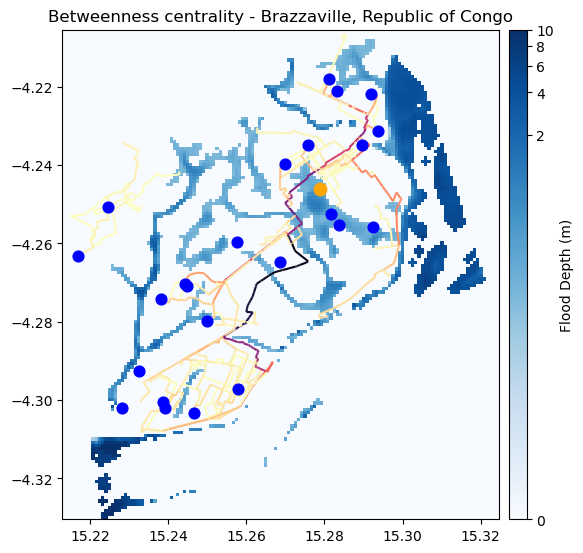

In [317]:
fig, ax = plt.subplots(figsize=(6, 8))
ax.set_title("Betweenness centrality - Brazzaville, Republic of Congo", fontsize=12, horizontalalignment='center')

# Plot the flood data
flood_image = show(flood_data, transform=flood.transform, ax=ax, norm=colors.PowerNorm(gamma=0.15), cmap='Blues', alpha = 1, zorder = 2)

# Create an axis divider for the colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size="4%", pad=0.1)

# Add the colorbar
cb = fig.colorbar(flood_image.get_images()[0], cax=cax, orientation='vertical')
cb.set_label("Flood Depth (m)")

# Plot the road network impcted
edges_df_flood.plot(ax = ax, column='centrality',  cmap='magma_r', zorder = 3)

# PLot the Health facilities flooded
hf_flooded.plot(ax=ax, color='orange', markersize = 80, zorder=3, label='HF flooded')
# Plot the Health facilities not affected
hf_dry.plot(ax=ax, color='blue', markersize = 60, zorder=3, label='HF (Not Impacted)')

ax.set_xlim(flood.bounds.left, flood.bounds.right)
ax.set_ylim(flood.bounds.bottom, flood.bounds.top)

plt.show()

If the centrality is reduced, the road is not a good backup one, indicating potential lack of resilience on that pathway. \
If the centrality is increased, on the other hand, that segment is a good backup road, and deserves attention during disasters and potential investments

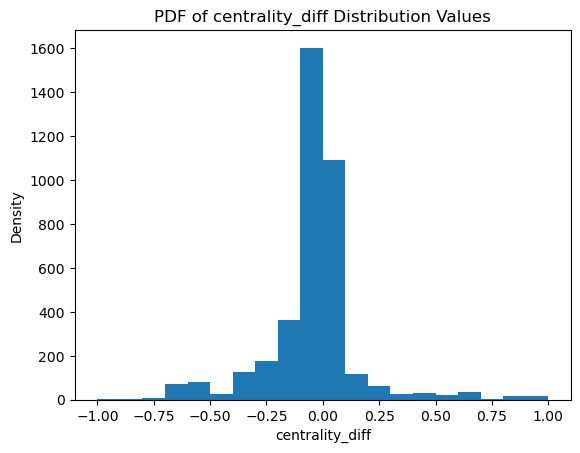

In [337]:
# Merge the dataframes on "osm_id"
centrality_diff = edges_df_flood.merge(edges_df, on="id", suffixes=('_flood', ''))
# Replace NaN with 0 
centrality_diff["centrality_flood"].fillna(0, inplace=True)
centrality_diff["centrality"].fillna(0, inplace=True)

# Calculate the centrality difference
centrality_diff["centrality_diff"] = centrality_diff["centrality_flood"] - centrality_diff["centrality"]
centrality_diff["centrality_diff"].replace(0, np.nan, inplace=True)

# centrality_diff

plt.hist(centrality_diff["centrality_diff"], bins = 20)
plt.title('PDF of centrality_diff Distribution Values')
plt.xlabel('centrality_diff')
plt.ylabel('Density')
plt.show()

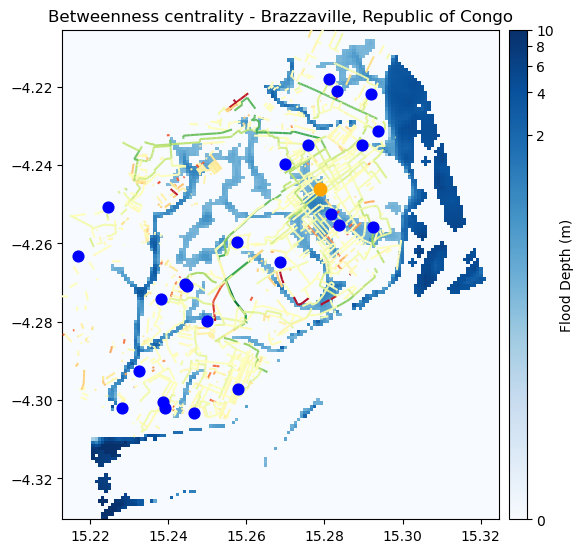

In [325]:
fig, ax = plt.subplots(figsize=(6, 8))
ax.set_title("Betweenness centrality - Brazzaville, Republic of Congo", fontsize=12, horizontalalignment='center')

# Plot the flood data
flood_image = show(flood_data, transform=flood.transform, ax=ax, norm=colors.PowerNorm(gamma=0.15), cmap='Blues', alpha = 1, zorder = 2)

# Create an axis divider for the colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size="4%", pad=0.1)

# Add the colorbar
cb = fig.colorbar(flood_image.get_images()[0], cax=cax, orientation='vertical')
cb.set_label("Flood Depth (m)")

# Plot the road network impacted
centrality_diff.plot(ax = ax, column='centrality_diff',  cmap='RdYlGn_r', zorder = 3)

# PLot the Health facilities flooded
hf_flooded.plot(ax=ax, color='orange', markersize = 80, zorder=3, label='HF flooded')
# Plot the Health facilities not affected
hf_dry.plot(ax=ax, color='blue', markersize = 60, zorder=3, label='HF (Not Impacted)')

ax.set_xlim(flood.bounds.left, flood.bounds.right)
ax.set_ylim(flood.bounds.bottom, flood.bounds.top)

# ax.legend(loc='lower right')

plt.show()

## Preprocessing



Align the POPULATION & FLOOD raster to the friction surface, ensuring that they have the same extent and resolution.

In [20]:
# If the Standardized data are already present, skip, else generate them

def checkDir(out_path):
    if not os.path.exists(out_path):
        os.makedirs(out_path)

out_pop_surface_std = join(out_path, iso, "WP_2020_1km_STD.tif")
if not os.path.isfile(out_pop_surface_std):
    rMisc.standardizeInputRasters(pop_surf, travel_surf, out_pop_surface_std, resampling_type="nearest")

checkDir(join(scratch_dir, 'data', iso, 'flood'))

for f,key in enumerate(flood_dict.keys()):
    # out_flood_path = join(data_dir, iso,'FLOOD_SSBN', 'Fmax_' + key)
    out_flood_std = join(out_path, iso, 'flood', "STD_" + 'Fmax_'+ key +'.tif')
    if os.path.isfile(out_flood_std):
        None
    else:
        rMisc.standardizeInputRasters(flood_dict[key], travel_surf, out_flood_std, resampling_type="nearest")

## Flood impact on Health facilities

Consider the raw Fmax flood rasters, thus exploiting the original FATHOM dataset resolution\
For every Standardized Flood layer (Return Period), extract Flood Depth on Health Facilities location

In [26]:
# Extract flood depth at every facility location

for key in flood_dict.keys():
    coords = [(x,y) for x, y in zip(geodf_hf_hosp.geometry.x, geodf_hf_hosp.geometry.y)]
    geodf_hf_hosp[key] = [x[0] for x in flood_dict[key].sample(coords)]

    coords = [(x,y) for x, y in zip(geodf_hf.geometry.x, geodf_hf.geometry.y)]
    geodf_hf[key] = [x[0] for x in flood_dict[key].sample(coords)]


In [27]:
# Identify Flooded and not Flooded Facilities 

flood_geodf_hf_hosp = {}
dry_geodf_hf_hosp = {}
flood_geodf_hf = {}
dry_geodf_hf = {}
for key in flood_dict.keys():
    flood_geodf_hf_hosp[key] = geodf_hf_hosp[geodf_hf_hosp[key] > 0.2]
    dry_geodf_hf_hosp[key] = geodf_hf_hosp[geodf_hf_hosp[key] == 0]
    
    flood_geodf_hf[key] = geodf_hf[geodf_hf[key] > 0.2]
    dry_geodf_hf[key] = geodf_hf[geodf_hf[key] == 0]


### Flood impact on Roads

Consider the raw Fmax flood rasters, thus exploiting the original FATHOM dataset resolution.

Assumptions:

- Floods impact all roads except primary and secondary bridges.
- Roads are disrupted if Flood Depth is > 20 cm.
- All-season road defined as primary and secondary or tertiary using the OpenStreetMap classification.

Load OSM roads and define classification 
``` python
{
    'motorway': 'OSMLR level 1',
    'motorway_link': 'OSMLR level 1',
    'trunk': 'OSMLR level 1',
    'trunk_link': 'OSMLR level 1',
    'primary': 'OSMLR level 1',
    'primary_link': 'OSMLR level 1',
    'secondary': 'OSMLR level 2',
    'secondary_link': 'OSMLR level 2',
    'tertiary': 'OSMLR level 2',
    'tertiary_link': 'OSMLR level 2',
    'unclassified': 'OSMLR level 3',
    'unclassified_link': 'OSMLR level 3',
    'residential': 'OSMLR level 3',
    'residential_link': 'OSMLR level 3',
    'track': 'OSMLR level 4',
    'service': 'OSMLR level 4'
}
 ```

In [ ]:
# Only for the first time, need to download OSM .shp

download_osm_shapefiles('africa', 'Congo (Republic/Brazzaville)', Path(join(data_dir, 'data', iso)))

In [27]:
# Load the Road network

roads = dask_gpd.read_file(join(data_dir, iso, "malawi-latest-free.shp", 'gis_osm_roads_free_1.shp'), npartitions = 8) #, chunksize = 100
roads = roads.to_crs(epsg)
roads['OSMLR'] = roads['fclass'].map(osm.OSMLR_Classes)
def get_num(x):
    try:
        return(int(x))
    except:
        return(5)
roads['OSMLR_num'] = roads['OSMLR'].apply(lambda x: get_num(str(x)[-1]))


In [28]:
# Create Polygons only from those cells where mask = True (water level >= 20 cm) 
def raster_cells_to_polygons(mask, transform):
    
    polygons = []
    for (row, col), value in np.ndenumerate(mask):
            if value:         # Only create polygons where the mask is True
                # Get the coordinates of the top left corner of the cell
                top_left = rio.transform.xy(transform, row, col, offset='ul')
                # Since each cell is a square, calculate the bottom right corner
                bottom_right = rio.transform.xy(transform, row+1, col+1, offset='ul')
                # Create a polygon from these coordinates
                polygon = box(top_left[0], bottom_right[1], bottom_right[0], top_left[1])
                polygons.append(polygon)
                
    return polygons

In [64]:
def flood_disruption_roads(roads_shp, flood_tif):

    flood_road = flood_tif.read(1).copy()
    # Floods can impact all the roads, except the bridges in primary and secondary roads
    roads_safe_crit = ((roads_shp['bridge'] == "T") & ((roads_shp['OSMLR_num'] == 1) | (roads_shp['OSMLR_num'] == 2)))
    roads_safe = roads_shp[roads_safe_crit]
    roads_flood = roads_shp[~roads_safe_crit]
    
    # If water level is more than 20 cm, the road is disrupted       
    flood_road = flood_road    # Need to explicitly open the rasterio within the dictionary to compute weights
    transf = flood_tif.transform
    mask = (flood_road >= 0.2)

    # Vectorize the masked cells
    flood_poly = raster_cells_to_polygons(mask, transf)
    flood_poly_gdf = gpd.GeoDataFrame(geometry=flood_poly, crs=epsg)  # Make sure to set the correct CRS

    # Remove the flooded roads
    intersections_dask = dask_gpd.sjoin(roads_flood[["osm_id", "fclass","bridge","geometry","OSMLR"]], flood_poly_gdf, how="inner", op='intersects')  
    intersections = intersections_dask.compute()
    intersections.drop_duplicates(subset="osm_id", inplace = True)

    # Convert from dask_gpd to gpd
    roads_shp = roads_shp.compute()
    roads_safe = roads_safe.compute()
    
    roads_impact = roads_shp.drop(intersections.index)

    # Add road types excluded from the analysis
    roads_final = pd.concat([roads_impact, roads_safe], axis = 0)
    
    # Export the disrupted roads shapefile
    roads_final.to_file(file, index = False)
    
    return roads_final

In [182]:
%%time

checkDir(join(out_path,iso,"vector"))

roads_impact = dict()
for key in flood_dict.keys():
    file = join(out_path,iso,"vector","roads_impact_"+key+"_new.shp")
    if not os.path.isfile(file):
        print("Computing scenario: " + key)
        roads_impact[key] = flood_disruption_roads(roads, flood_dict[key])
    else:
        print("Reading " + file)
        roads_impact[key] = dask_gpd.read_file(file, npartitions = 8)

Reading /home/jupyter-wb618081/Health-Access-Metrics/Output/MWI/vector/roads_impact_1in500_new.shp
Reading /home/jupyter-wb618081/Health-Access-Metrics/Output/MWI/vector/roads_impact_1in20_new.shp
Reading /home/jupyter-wb618081/Health-Access-Metrics/Output/MWI/vector/roads_impact_1in75_new.shp
Reading /home/jupyter-wb618081/Health-Access-Metrics/Output/MWI/vector/roads_impact_1in50_new.shp
Reading /home/jupyter-wb618081/Health-Access-Metrics/Output/MWI/vector/roads_impact_1in5_new.shp
Reading /home/jupyter-wb618081/Health-Access-Metrics/Output/MWI/vector/roads_impact_1in100_new.shp
Reading /home/jupyter-wb618081/Health-Access-Metrics/Output/MWI/vector/roads_impact_1in250_new.shp
Reading /home/jupyter-wb618081/Health-Access-Metrics/Output/MWI/vector/roads_impact_1in1000_new.shp
Reading /home/jupyter-wb618081/Health-Access-Metrics/Output/MWI/vector/roads_impact_1in200_new.shp
Reading /home/jupyter-wb618081/Health-Access-Metrics/Output/MWI/vector/roads_impact_1in10_new.shp
CPU times: user

### Access to Roads

Percentage of Health Facilities having direct access to an all-season road, by district (admin-2 level).​

Assumptions:

- All Health facilities considered are: Hospital, Health Post, Village Clinic, Health Centre, Dispensary and Outreach
- All-season road defined as primary and secondary or tertiary using the OpenStreetMap classification.
- Direct access defined as being within 100 m and 2 km of a road.​

In [122]:
import geopandas as gpd

def roads_access_buffer(dest_gdf, roads_gdf, buffer_dist=100, utm=epsg_utm, road_importance=None):
    ''' 
    Compute the accessibility of destinations according to their distance from roads
    
    INPUT
    dest_gdf [geopandas.GeoDataFrame] - destinations GeoDataFrame from which to compute roads access
    roads_gdf [geopandas.GeoDataFrame] - roads GeoDataFrame from which to apply the buffer distance
    buffer_dist [int] - buffer distance in meters
    utm [str] - UTM projection to use
    road_importance [int, optional] - threshold for road importance
    
    RETURNS
    geopandas.GeoDataFrame - destinations GeoDataFrame with boolean access column
    '''
    
    dest_gdf_buff = dest_gdf.copy().to_crs(utm)
    
    # Calculate buffers
    roads_buff = roads_gdf.copy().to_crs(utm)
    roads_buff['geometry'] = roads_buff['geometry'].buffer(buffer_dist)
    
    # Filter roads based on importance if specified
    if road_importance is not None:
        roads_buff = roads_buff.loc[roads_buff['OSMLR_num'] <= road_importance]
    
    # Intersect roads and buffer
    matched_index = gpd.sjoin(dest_gdf_buff, roads_buff, how="inner", op='intersects').index

    # Create dynamic column name
    col_name = f'bool_{road_importance}_{buffer_dist}m' if road_importance is not None else f'bool_all_{buffer_dist}m'
    dest_gdf_buff[col_name] = dest_gdf_buff.index.isin(matched_index)
        
    dest_gdf_buff = dest_gdf_buff.to_crs(dest_gdf.crs)
    
    return dest_gdf_buff


In [123]:
def roads_access_buffer_dask(dest_gdf, roads_gdf, buffer_dist=100, utm='epsg:utm', road_importance=None):
    ''' 
    Compute the accessibility of destinations according to their distance from roads
    
    INPUT
    dest_gdf [dask_geopandas.GeoDataFrame] - destinations GeoDataFrame from which to compute roads access
    roads_gdf [dask_geopandas.GeoDataFrame] - roads GeoDataFrame from which to apply the buffer distance
    buffer_dist [int] - buffer distance in meters
    utm [str] - UTM projection to use
    road_importance [int, optional] - threshold for road importance
    
    RETURNS
    dask_geopandas.GeoDataFrame - destinations GeoDataFrame with boolean access column
    '''
    
    # Convert coordinate reference systems
    dest_gdf_buff = dest_gdf.map_partitions(lambda df: df.to_crs(utm), meta=gpd.GeoDataFrame())
    roads_buff = roads_gdf.map_partitions(lambda df: df.to_crs(utm), meta=gpd.GeoDataFrame())
    
    # Calculate buffers
    roads_buff['geometry'] = roads_buff['geometry'].map_partitions(lambda x: x.buffer(buffer_dist))
    
    # Filter roads based on importance if specified
    if road_importance is not None:
        roads_buff = roads_buff.query(f'OSMLR_num <= {road_importance}')
    
    # Intersect roads and buffer
    dest_gdf_buff = dask_gpd.sjoin(dest_gdf_buff, roads_buff, how="inner", predicate='intersects')
    
    # Create dynamic column name
    col_name = f'bool_{road_importance}_{buffer_dist}m_baseline' if road_importance is not None else f'bool_all_{buffer_dist}m_baseline'
    
    # Intersect roads and buffer using map_partitions
    def spatial_join_and_create_column(dest, roads, col_name):
        joined = gpd.sjoin(dest, roads, how="inner", predicate='intersects')
        dest[col_name] = dest.index.isin(joined.index)
        return dest
   
    dest_gdf = dest_gdf.map_partitions(lambda df: spatial_join_and_create_column(df, roads_gdf.compute(), col_name), meta=gpd.GeoDataFrame())
    
    # final_gdf = final_gdf.to_crs(dest_gdf.crs)
    final_gdf = final_gdf.map_partitions(lambda df: df.to_crs(dest_gdf.crs), meta=gpd.GeoDataFrame())

    out_gdf = final_gdf.compute()
    
    return out_gdf

# Example usage (assuming you have Dask GeoDataFrames `dask_dest_gdf` and `dask_roads_gdf`)
# result = roads_access_buffer(dask_dest_gdf, dask_roads_gdf, buffer_dist=100, utm='epsg:32633', road_importance=2)
# result.compute() # To trigger computation and get the final GeoDataFrame

%%time

geodf_hf_dask = dask_gpd.from_geopandas(geodf_hf, npartitions=8)
roads_access_buffer_dask(geodf_hf_dask, roads, buffer_dist=100, utm=epsg_utm, road_importance=2)

#### Baseline

In [154]:
%%time

data_health = geodf_hf.copy()
buffer_zones = [100, 2000]
for b in buffer_zones:
    content = roads_access_buffer(geodf_hf, roads_impact[key].compute(), buffer_dist=b, utm=epsg_utm, road_importance=2).filter(regex='^bool_')
    col = content.columns[0]
    content = content.rename(columns={col:col + "_baseline"})
    data_health = pd.concat([data_health, content], axis = 1)

CPU times: user 3min 34s, sys: 46.6 s, total: 4min 21s
Wall time: 4min 20s


In [216]:
adm1 = adm1.to_crs(epsg)
geodf_hf_road_base = gpd.sjoin(data_health, adm1[['geometry']], how='left').drop(columns = "index_right")

## Get percentages
res_osmlr = geodf_hf_road_base[['bool_2_100m_baseline','bool_2_2000m_baseline','ADM1']].groupby('ADM1').sum().compute()
res_count = geodf_hf_road_base[['ADM1','bool_2_100m_baseline']].groupby('ADM1').count().rename(columns={'bool_2_100m_baseline':'count'}).compute()
res_osmlr_pct_base = res_osmlr.apply(lambda x: (x/res_count['count'])*100)
res_osmlr_pct_base.reset_index(inplace = True)

res_osmlr_pct_base.head(2)

#### Flood Scenarios

In [211]:
%%time

data_health = geodf_hf.copy()
for key in roads_impact.keys():

    buffer_zones = [100, 2000]
    for b in buffer_zones:
        content = roads_access_buffer(geodf_hf, roads_impact[key].compute(), buffer_dist=b, utm=epsg_utm, road_importance=2).filter(regex='^bool_')
        col = content.columns[0]
        content = content.rename(columns={col:col + "_" + key})
        data_health = pd.concat([data_health, content], axis = 1)

CPU times: user 2min 8s, sys: 653 ms, total: 2min 9s
Wall time: 2min 8s


In [214]:
adm1 = adm1.to_crs(epsg)

geodf_hf_road = gpd.sjoin(data_health, adm1[['geometry']], how='left').drop(columns = "index_right")
## Get percentages
# res_osmlr = facilities[['bool_1_100m','bool_2_100m','bool_1_2km','bool_2_2km','WB_ADM2_CO']].groupby('WB_ADM2_CO').sum()
columns = [col for col in geodf_hf_road.columns if col.startswith("bool")]
res_osmlr = geodf_hf_road[columns+['ADM1']].groupby('ADM1').sum()
res_count = geodf_hf_road[["bool_2_100m_"+key,'ADM1']].groupby('ADM1').count().rename(columns={'bool_2_100m_'+key:'count'})
res_osmlr_pct = res_osmlr.apply(lambda x: (x/res_count['count'])*100)
res_osmlr_pct.reset_index(inplace = True)

res_osmlr_pct.head(2)

,ADM1,bool_2_100m_baseline_1in500,bool_2_2000m_baseline_1in500
0,Balaka,3.750000,27.812500
1,Blantyre,4.347826,39.130435


In [ ]:
geo_res_osmlr_pct_base = gpd.GeoDataFrame(res_osmlr_pct_base, geometry=adm1.geometry, crs=epsg)
geo_res_osmlr_pct = gpd.GeoDataFrame(res_osmlr_pct, geometry=adm1.geometry, crs=epsg)

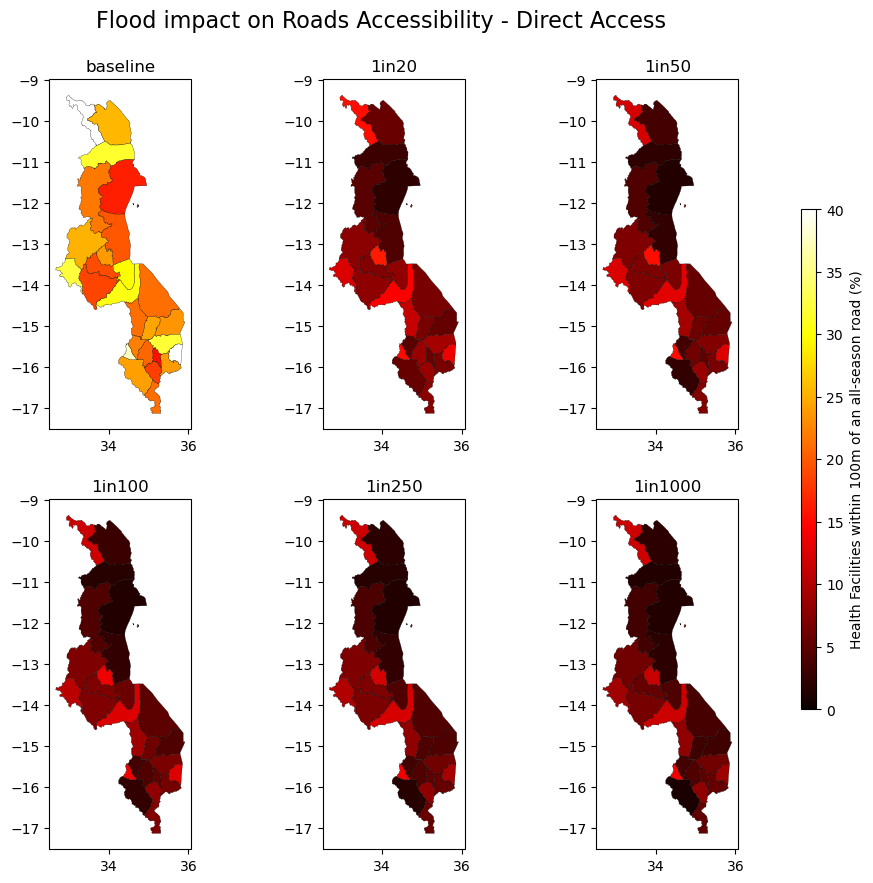

In [279]:
import matplotlib.gridspec as gridspec
import cartopy.feature as cfeature
os.environ['CARTOPY_USER_BACKGROUNDS'] = 'C:/Users/wb618081/OneDrive - WBG/Python/Backgrounds/'

figsize = (10,10)
fig = plt.figure(figsize=figsize) #, constrained_layout=True)
projection = ccrs.PlateCarree()
gs = gridspec.GridSpec(2, 3)

fig.suptitle("Flood impact on Roads Accessibility - Direct Access", size = 16, y = 0.95)
# fonttitle = {'fontname':'Open Sans','weight':'bold','size':14}

# Define the colormap
cmap = plt.get_cmap('hot')
# Define the normalization from 0 to 45
norm = colors.Normalize(vmin=0, vmax=40)

scen_toplot = ["baseline", '1in20', '1in50', '1in100', '1in250', '1in1000']
for i, flood in enumerate(scen_toplot):
    if i < 3:
        ax = fig.add_subplot(gs[0, i], projection=projection)
    else:
        ax = fig.add_subplot(gs[1, i-3], projection=projection)

    ax.set_title(flood)
    ax.get_xaxis().set_visible(True)
    ax.get_yaxis().set_visible(True)

    
    # Plot the data
    if i == 0:
        geo_res_osmlr_pct_base.plot(
        ax=ax, column="bool_2_100m_"+flood, cmap=cmap, legend=False,
        alpha=1, linewidth=0.2, edgecolor='black', 
        norm = norm
    )

    else:
        geo_res_osmlr_pct.plot(
        ax=ax, column="bool_2_100m_"+flood, cmap=cmap, legend=False,
        alpha=1, linewidth=0.2, edgecolor='black', 
        norm=norm
    )

    ax.background_img(name='NaturalEarthRelief', resolution='high', extent = [32.5, 36, -18, -9])

cax = fig.add_axes([0.92, 0.25, 0.015, 0.5])  # Adjust the position and size of the colorbar here
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=cax, label="Health Facilities within 100m of an all-season road (%)")

plt.show()

# plt.savefig(os.path.join(scratch_dir, "Health_Access.png"), dpi=150, bbox_inches='tight', facecolor='white')

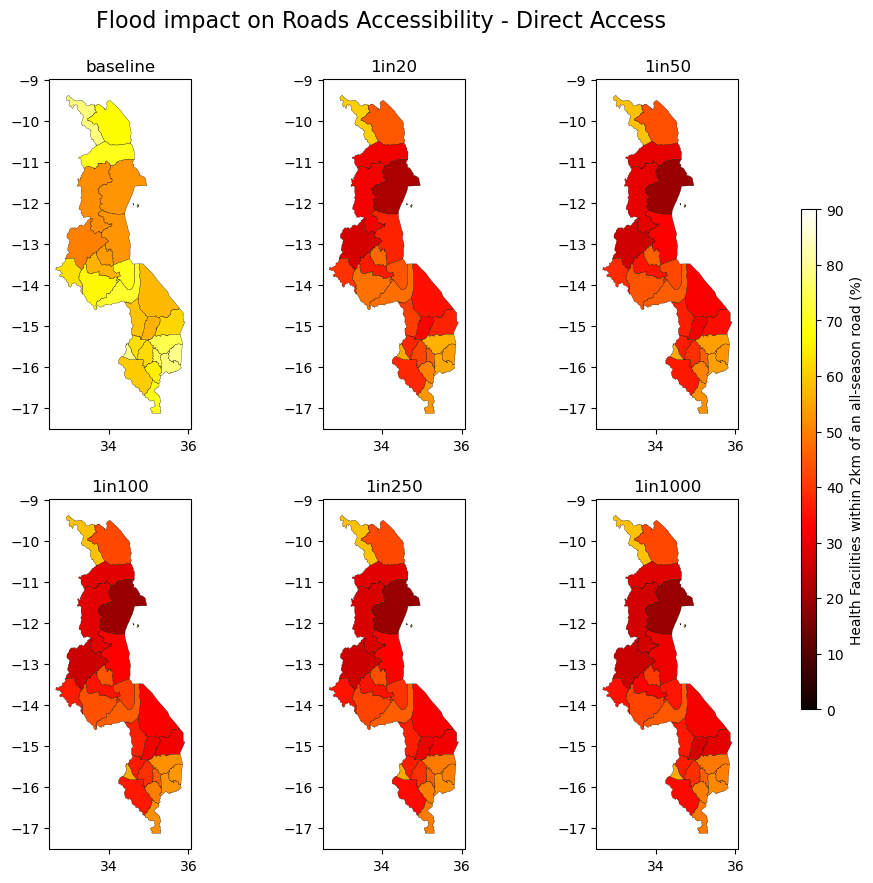

In [290]:
import matplotlib.gridspec as gridspec
import cartopy.feature as cfeature
os.environ['CARTOPY_USER_BACKGROUNDS'] = 'C:/Users/wb618081/OneDrive - WBG/Python/Backgrounds/'

figsize = (10,10)
fig = plt.figure(figsize=figsize) #, constrained_layout=True)
projection = ccrs.PlateCarree()
gs = gridspec.GridSpec(2, 3)

fig.suptitle("Flood impact on Roads Accessibility - Direct Access", size = 16, y = 0.95)
# fonttitle = {'fontname':'Open Sans','weight':'bold','size':14}

# Define the colormap
cmap = plt.get_cmap('hot')
# Define the normalization from 0 to 45
norm = colors.Normalize(vmin=0, vmax=90)

scen_toplot = ["baseline", '1in20', '1in50', '1in100', '1in250', '1in1000']
for i, flood in enumerate(scen_toplot):
    if i < 3:
        ax = fig.add_subplot(gs[0, i], projection=projection)
    else:
        ax = fig.add_subplot(gs[1, i-3], projection=projection)

    ax.set_title(flood)
    ax.get_xaxis().set_visible(True)
    ax.get_yaxis().set_visible(True)

    
    # Plot the data
    if i == 0:
        geo_res_osmlr_pct_base.plot(
        ax=ax, column="bool_2_2km_"+flood, cmap=cmap, legend=False,
        alpha=1, linewidth=0.2, edgecolor='black', 
        norm = norm
    )

    else:
        geo_res_osmlr_pct.plot(
        ax=ax, column="bool_2_2km_"+flood, cmap=cmap, legend=False,
        alpha=1, linewidth=0.2, edgecolor='black', 
        norm=norm
    )


    ax.background_img(name='NaturalEarthRelief', resolution='high', extent = [32.5, 36, -18, -9])

cax = fig.add_axes([0.92, 0.25, 0.015, 0.5])  # Adjust the position and size of the colorbar here
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=cax, label="Health Facilities within 2km of an all-season road (%)")

plt.show()

# plt.savefig(os.path.join(scratch_dir, "Health_Access.png"), dpi=150, bbox_inches='tight', facecolor='white')

### Access to health disaggregated by wealth quintile

Categorize population grid by wealth quintiles, and then summarize the population with access to health (within 2 hours of health facility or hospital)

Hospitals

In [288]:
# Open Relative Wealth index and Population from Facebook
df_fb_rwi = pd.read_csv(os.path.join(data_dir, iso, 'meta', f'{iso.lower()}_relative_wealth_index.csv'))
geodf_fb = [Point(xy) for xy in zip(df_fb_rwi.longitude, df_fb_rwi.latitude)]
geodf_fb = gpd.GeoDataFrame(df_fb_rwi, crs=epsg, geometry=geodf_fb)
geodf_fb = gpd.sjoin(geodf_fb, adm1[['ADM1','geometry']])

df_fb_pop = pd.read_csv(os.path.join(data_dir, iso, 'meta', f'{iso.lower()}_general_2020.csv'))
df_fb_pop = df_fb_pop.rename(columns={f'{iso.lower()}_general_2020': 'pop_2020'})
    
df_fb_flood_hosp = dict()
for key in tt_rio_hosp.keys():

    # Zonal mean of RWI in tt_rio_hosp cells
    df_fb_flood_hosp[key] = pd.DataFrame(zonal_stats(geodf_fb, tt_rio_hosp[key].read(1, masked = True).filled(), affine=tt_rio_hosp[key].transform, stats='mean', nodata=tt_rio_hosp[key].nodata)).rename(columns={'mean':'tt_hospital_'+key})
    geodf_fb = geodf_fb.join(df_fb_flood_hosp[key])

    # Discretize in quantiles
    geodf_fb.loc[:, "rwi_cut_"+key] = pd.qcut(geodf_fb['rwi'], [0, .2, .4, .6, .8, 1.], labels=['lowest', 'second-lowest', 'middle', 'second-highest', 'highest'])
    
    # Merge RWI and population by matching the grid (quadkey)
    df_fb_pop['quadkey'+key] = df_fb_pop.apply(lambda x: str(quadkey.from_geo((x['latitude'], x['longitude']), 14)), axis=1)
    geodf_fb['quadkey'+key] = geodf_fb.apply(lambda x: str(quadkey.from_geo((x['latitude'], x['longitude']), 14)), axis=1)
    bing_tile_z14_pop = df_fb_pop.groupby('quadkey'+key, as_index=False)['pop_2020'].sum()

    rwi = geodf_fb.merge(bing_tile_z14_pop[['quadkey'+key, 'pop_2020']], on='quadkey'+key, how='inner')

res_rwi_adm0 = pd.DataFrame()
res_rwi_adm1 = pd.DataFrame()
for key in tt_rio_hosp.keys():

    # Define boolean proximity within 2hrs from hospital
    rwi.loc[:,"tt_hospital_bool_" + key] = rwi['tt_hospital_'+key]<=2
    
    # Aggregate at country level (ADM0)
    pop_adm0 = rwi[['rwi_cut_'+key, 'pop_2020']].groupby(['rwi_cut_'+key]).sum()
    hosp_adm0 = rwi.loc[rwi["tt_hospital_bool_" + key]==True, ['rwi_cut_'+key, 'pop_2020']].groupby(['rwi_cut_'+key]).sum().rename(columns={'pop_2020':'pop_120_hospital_'+key})
    rwi_adm0 = pop_adm0.join(hosp_adm0)
    res_rwi_adm0.loc[:, "hospital_pct_"+key] = rwi_adm0['pop_120_hospital_'+key]/rwi_adm0['pop_2020']

    # Aggregate at region level (ADM1)
    pop_adm1 = rwi[['ADM1','rwi_cut_'+key, 'pop_2020']].groupby(['ADM1','rwi_cut_'+key]).sum()
    hosp_adm1 = rwi.loc[rwi["tt_hospital_bool_" + key]==True, ['ADM1','rwi_cut_'+key, 'pop_2020']].groupby(['ADM1','rwi_cut_'+key]).sum().rename(columns={'pop_2020':'pop_120_hospital_'+key})
    rwi_adm1 = pop_adm1.join(hosp_adm1)
    res_rwi_adm1.loc[:, "hospital_pct_"+key] = rwi_adm1['pop_120_hospital_'+key]/rwi_adm1['pop_2020']

res_rwi_adm0.reset_index(inplace = True)
res_rwi_adm0 = res_rwi_adm0.rename(columns={'rwi_cut_1in5':'quantiles'})

res_rwi_adm1.reset_index(inplace = True)
res_rwi_adm1 = res_rwi_adm1.rename(columns={'rwi_cut_1in5':'quantiles'})


In [324]:
def sort_flood_col(gdf, str_start, str_sep):
    # Define str_start and str_sep as the strings that identify the start of column names and the separator with the numerical value
    fd_columns = [col for col in gdf.columns if str_start in col]
    non_fd_columns = [col for col in gdf.columns if not str_start in col]
    fd_num = [(int(col.split(str_sep)[1]), col) for col in fd_columns]
    fd_col_sort = [col for _, col in sorted(fd_num)]
    new_column_order = non_fd_columns + fd_col_sort
    # Reorder the DataFrame columns
    gdf = gdf[new_column_order]
    return(gdf)

In [329]:
# Melting for seaborn plot
res_rwi_adm0 = sort_flood_col(res_rwi_adm0, "1in", "in")
res_rwi_adm0_long = pd.melt(res_rwi_adm0, id_vars="quantiles", var_name="scen")
res_rwi_adm0_long.value = res_rwi_adm0_long.value*100
scen = res_rwi_adm0_long.scen.unique()
scen = [s.split("_")[2] for s in scen]

res_rwi_adm1 = sort_flood_col(res_rwi_adm1, "1in", "in")
res_rwi_adm1_long = pd.melt(res_rwi_adm1, id_vars=["ADM1","quantiles"], var_name="scen")
res_rwi_adm1_long.value = res_rwi_adm1_long.value*100

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


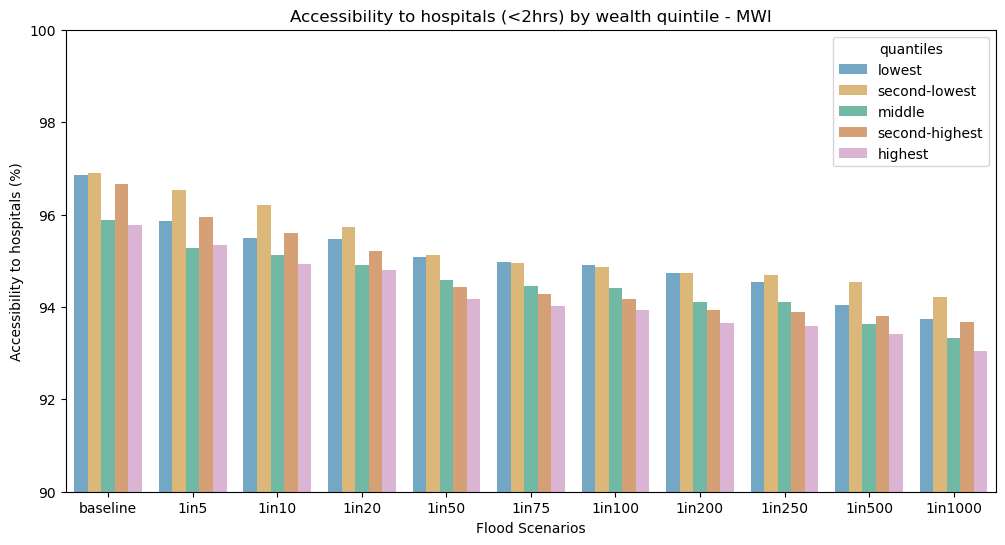

In [357]:
fig = plt.figure(figsize=(12, 6))

ax0 = fig.add_subplot(111)
ax0.set_title("Accessibility to hospitals (<2hrs) by wealth quintile - " + iso)
ax0.set_xticklabels(scen)
ax0.set_xlabel("Flood Scenarios")
ax0.set_ylabel("Accessibility to hospitals (%)")
ax0.set_ylim(90,100)
ax0.legend(loc='upper left', fontsize = 10, title = "RWI quantiles")
ax0 = sns.barplot(
    data=res_rwi_adm0_long, hue="quantiles",# errorbar=("pi", 50),
    x="scen", y="value",
    palette='colorblind', alpha=.6, 
)

In [500]:
res_rwi_adm1["hospital_pct_impact"] = (res_rwi_adm1["hospital_pct_1in1000"] - res_rwi_adm1["hospital_pct_baseline"])/res_rwi_adm1["hospital_pct_baseline"]

In [501]:
test = res_rwi_adm1.copy()
test = test[["ADM1", "quantiles", "hospital_pct_impact"]]

quant = pd.DataFrame(test["ADM1"].unique())
for q in test.quantiles.unique().to_list():
    quant["hospital_pct_impact_"+ q] = test[test["quantiles"] == q]["hospital_pct_impact"].values.round(3)*100
    
quant = quant.rename(columns = {quant.columns[0]:"ADM1"})
quant = quant.merge(right = adm1[["ADM1",'geometry']], on = "ADM1", how = "left")
quant = gpd.GeoDataFrame(quant, crs=epsg, geometry="geometry")
# quant = quant*100
quant.head(2)

,ADM1,hospital_pct_impact_lowest,hospital_pct_impact_second-lowest,hospital_pct_impact_middle,hospital_pct_impact_second-highest,hospital_pct_impact_highest,geometry
0,Balaka,0.0,-0.5,-2.1,-2.0,-1.5,"MULTIPOLYGON (((35.07923 -15.30382, 35.07925 -..."
1,Blantyre,-5.5,-2.1,0.0,-6.6,-2.1,"MULTIPOLYGON (((34.94884 -15.98430, 34.94793 -..."


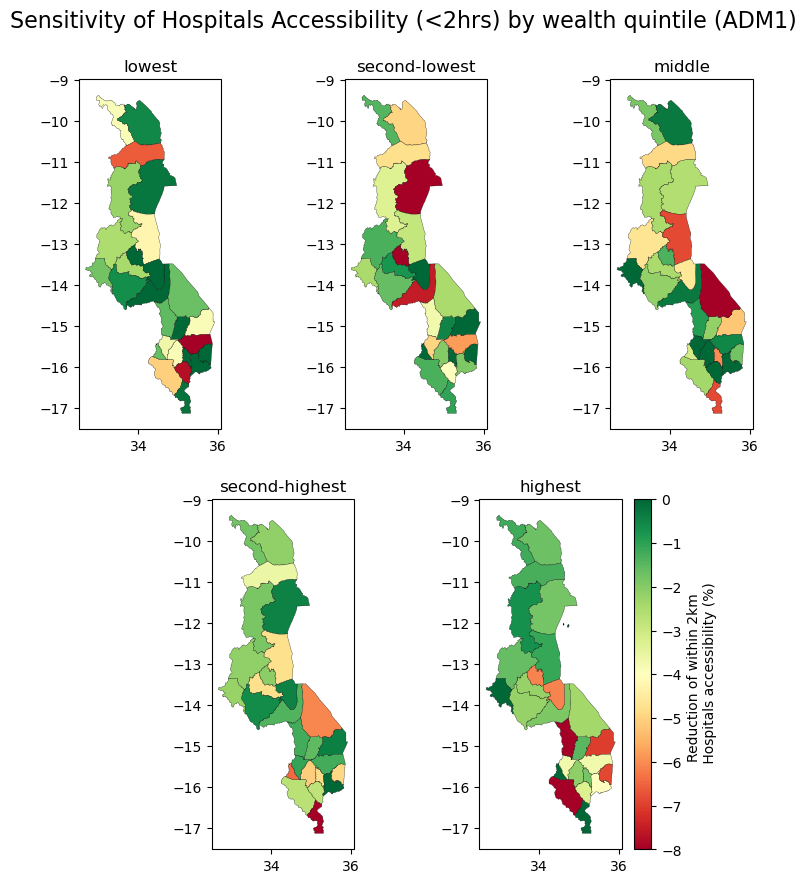

In [502]:
import matplotlib.gridspec as gridspec
import cartopy.feature as cfeature
os.environ['CARTOPY_USER_BACKGROUNDS'] = 'C:/Users/wb618081/OneDrive - WBG/Python/Backgrounds/'

figsize = (10,10)
fig = plt.figure(figsize=figsize) #, constrained_layout=True)
projection = ccrs.PlateCarree()
gs = gridspec.GridSpec(2, 6)

fig.suptitle("Sensitivity of Hospitals Accessibility (<2hrs) by wealth quintile (ADM1)", size = 16, y = 0.95)
# fonttitle = {'fontname':'Open Sans','weight':'bold','size':14}

for i, q in enumerate(quant.columns[1:6]):
    if i < 3:
        ax = fig.add_subplot(gs[0, 2 * i : 2 * i + 2], projection=projection)
    else:
        ax = fig.add_subplot(gs[1, 2 * i - 5 : 2 * i - 3], projection=projection)

    ax.set_title(q.split("_")[3])
    ax.get_xaxis().set_visible(True) # plt.axis('off')
    ax.get_yaxis().set_visible(True)
    
    cmap = "RdYlGn"

    if i == 4:
        quant.plot(
        ax=ax, column=q, cmap=cmap, legend=True,
        alpha=1, linewidth=0.2, edgecolor='black', 
        # scheme = "user defined", classification_kwds = {'bins': [-0.02,-0.04,-0.6,-0.08,-0.10,-0.12]},
        legend_kwds = {
            'label': "Reduction of within 2km \n Hospitals accessibility (%)",
            # "loc": "upper right",
            # "bbox_to_anchor": (2.7, 1), 
            # 'fontsize': 10,
            # 'fmt': "{:.0%}",
            # 'title_fontsize': 12
        }
    )
    else:
        quant.plot(
        ax=ax, column=q, cmap=cmap, legend=False,
        alpha=1, linewidth=0.2, edgecolor='black', 
        # scheme = "naturalbreaks", classification_kwds = {'bins': [-0.02,-0.04,-0.6,-0.08,-0.10,-0.12]},
        legend_kwds = {
            'title': "Reduction of within 2km \n Hospitals accessibility (%)",
            "loc": "upper right",
            "bbox_to_anchor": (2.7, 1), 
            'fontsize': 10,
            'fmt': "{:.0%}",
            'title_fontsize': 12
        }
    )
        
    # ax.background_img(name='NaturalEarthRelief', resolution='high', extent = [32.5, 36, -18, -9])

# plt.savefig(os.path.join(scratch_dir, "Health_Access.png"), dpi=150, bbox_inches='tight', facecolor='white')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


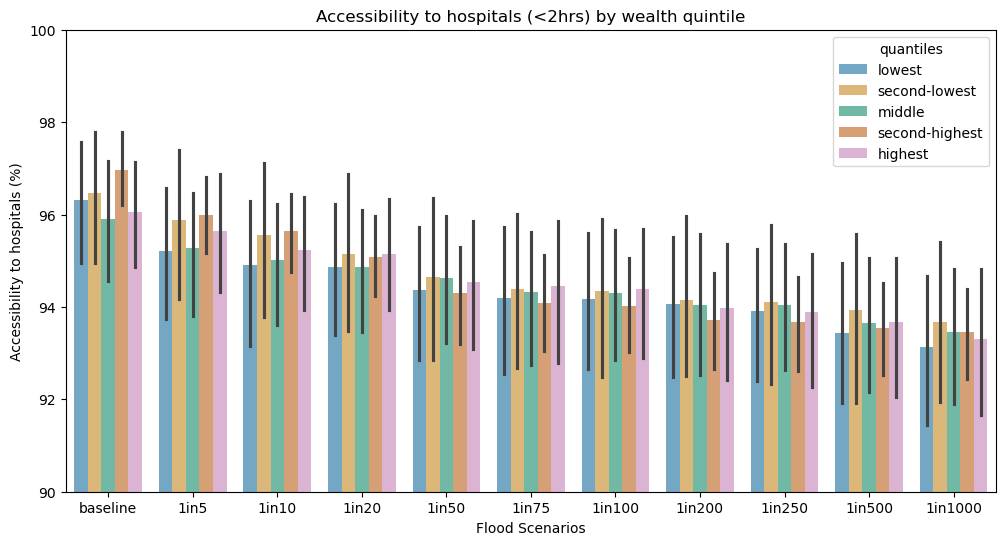

In [355]:
fig = plt.figure(figsize=(12, 6))

ax0 = fig.add_subplot(111)
ax0.set_title("Accessibility to hospitals (<2hrs) by wealth quintile")
ax0.set_xticklabels(scen)
ax0.set_xlabel("Flood Scenarios")
ax0.set_ylabel("Accessibility to hospitals (%)")
ax0.set_ylim(90,100)
ax0.legend(loc='upper left', fontsize = 10, title = "RWI quantiles")
ax0 = sns.barplot(
    data=res_rwi_adm1_long, hue="quantiles",# errorbar=("pi", 50),
    x="scen", y="value",
    palette='colorblind', alpha=.6, 
)